In [4]:
# Imports first
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Settings after
warnings.filterwarnings('ignore')
plt.style.use('dark_background')
print("Libraries loaded!")

Libraries loaded!


In [11]:
df = pd.read_csv('../data/processed/british_gp_2023_clean.csv')
df.head()

,Driver,Team,LapNumber,LapTime,Stint,TyreLife,Compound,PitInTime,PitOutTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsAccurate,LapTimeSeconds
0,VER,Red Bull Racing,2.0,0 days 00:01:33.433000,1.0,2.0,MEDIUM,NaN,NaN,290.0,255.0,244.0,291.0,True,93.433
1,VER,Red Bull Racing,3.0,0 days 00:01:32.730000,1.0,3.0,MEDIUM,NaN,NaN,311.0,259.0,245.0,318.0,True,92.730
2,VER,Red Bull Racing,4.0,0 days 00:01:32.780000,1.0,4.0,MEDIUM,NaN,NaN,313.0,259.0,245.0,316.0,True,92.780
3,VER,Red Bull Racing,5.0,0 days 00:01:32.582000,1.0,5.0,MEDIUM,NaN,NaN,320.0,254.0,244.0,288.0,True,92.582
4,VER,Red Bull Racing,6.0,0 days 00:01:33.027000,1.0,6.0,MEDIUM,NaN,NaN,290.0,255.0,245.0,285.0,True,93.027


In [13]:
df.shape

(802, 15)

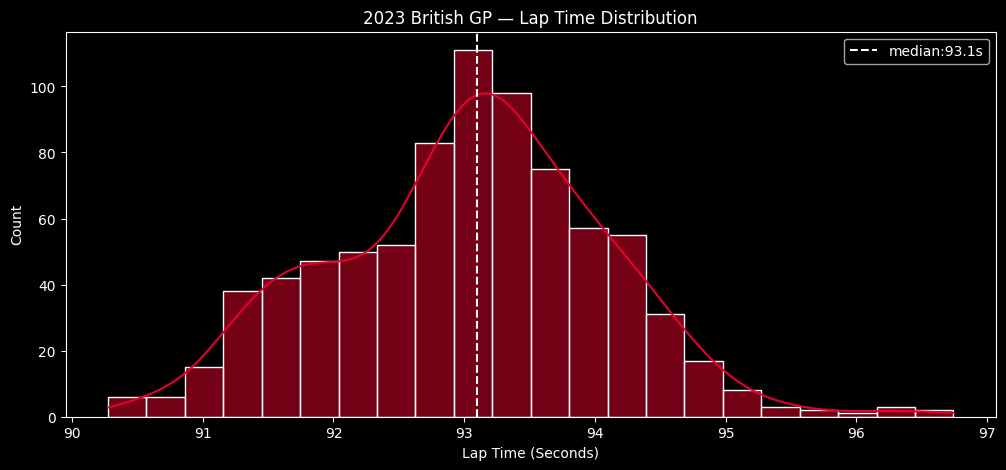

<Figure size 640x480 with 0 Axes>

In [21]:
fig, ax = plt.subplots(figsize = (12, 5))
sns.histplot(data = df, color='#E8002D', x='LapTimeSeconds',kde = True, ax=ax)
ax.set_xlabel('Lap Time (Seconds)')
ax.set_title('2023 British GP — Lap Time Distribution')
median_lap = df['LapTimeSeconds'].median()
ax.axvline(median_lap, color = 'white', linestyle = '--', label = f'median:{median_lap:.1f}s')
ax.legend()
plt.show()
fig.patch.set_facecolor('#1a1a1a')
plt.savefig('../data/charts/lap_time_distribution.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())

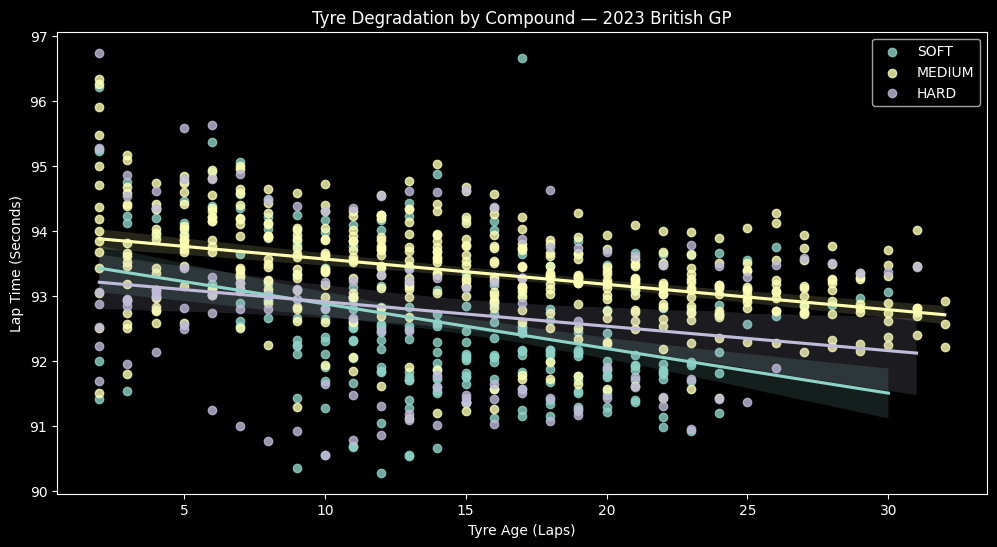

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

for compound in ['SOFT', 'MEDIUM', 'HARD']:
    compound_data = df[df['Compound'] == compound]

    sns.regplot(
        data = compound_data,
        x = 'TyreLife',
        y = 'LapTimeSeconds',
        label = compound,
        ax=ax
    )

ax.set_xlabel('Tyre Age (Laps)')
ax.set_ylabel('Lap Time (Seconds)')
ax.set_title('Tyre Degradation by Compound — 2023 British GP')
ax.legend()
plt.show()

In [24]:
df.groupby('Driver')['LapTimeSeconds'].median().sort_values()

Driver
VER    92.2950
NOR    92.7210
PIA    92.7405
HAM    92.8000
LEC    92.8315
RUS    92.8510
SAI    92.9910
PER    93.0405
ALO    93.0520
ALB    93.1690
TSU    93.2115
GAS    93.2870
HUL    93.3410
SAR    93.4960
STR    93.4980
BOT    93.5440
ZHO    93.6010
DEV    93.6470
OCO    94.1130
MAG    94.2955
Name: LapTimeSeconds, dtype: float64

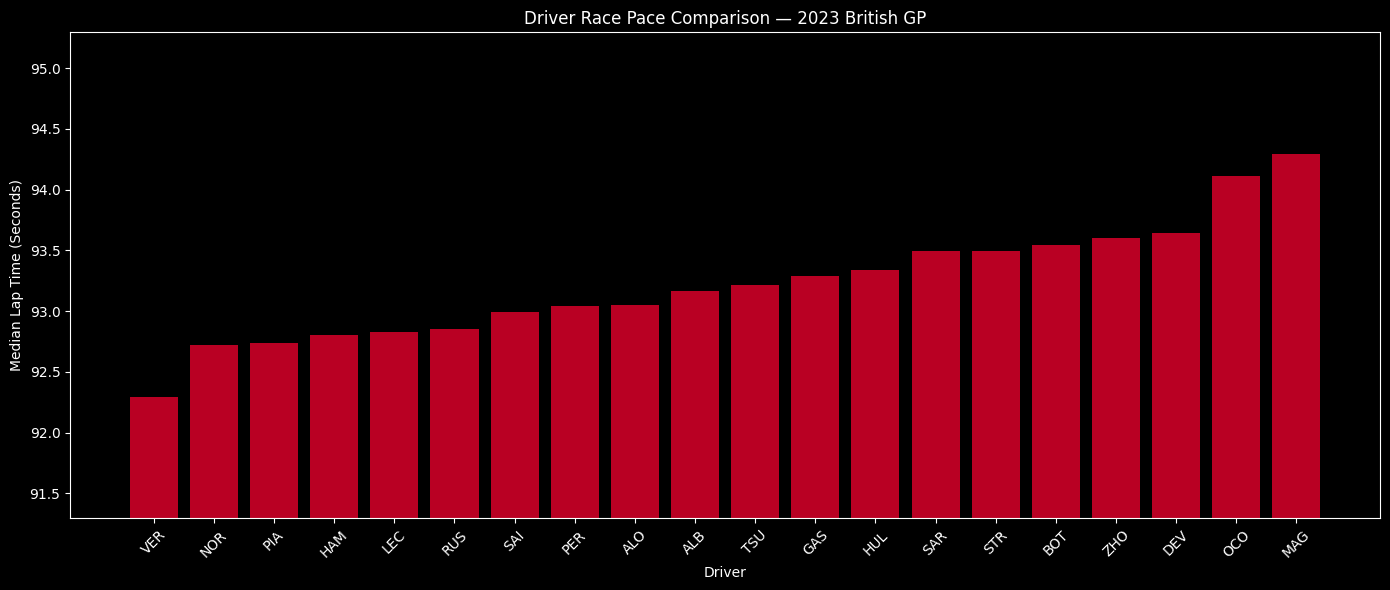

In [26]:
fig, ax = plt.subplots(figsize=(14, 6))

# Calculate median lap time per driver, sorted fastest first
driver_pace = df.groupby('Driver')['LapTimeSeconds'].median().sort_values()

# Plot as a bar chart
ax.bar(driver_pace.index, driver_pace.values, color='#E8002D', alpha=0.8)

ax.set_xlabel('Driver')
ax.set_ylabel('Median Lap Time (Seconds)')
ax.set_title('Driver Race Pace Comparison — 2023 British GP')
ax.set_ylim(driver_pace.min() - 1, driver_pace.max() + 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()